# Step 4: Model benchmark

This notebook summarizes saved model predictions on the synthetic test set and real-world MINDS-14. It does not retrain models or create new train/validation/test splits.

## 1. Set the seed, paths, and model metadata

Use the shared seed 42 and import the approved metric and bootstrap functions. The metadata follows Section 2 of the task plan; the starred type labels remain lecture-dependent as noted in the plan.

In [1]:
import random
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import Markdown, display
from sklearn.metrics import accuracy_score, f1_score

import sys
sys.path.insert(0, '..')
from src.bootstrap import bootstrap_ci, paired_bootstrap_diff

SEED = 42
N_BOOT = 1000
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

PREDICTION_DIR = Path('../results/predictions')
RESULTS_DIR = Path('../results')
MODEL_METADATA = {
    'tfidf_lr': {
        'type': 'baseline',
        'architecture': 'bag of words + linear classifier',
        'specific_model': 'trained from scratch',
    },
    'sbert_svm': {
        'type': 'baseline / new*',
        'architecture': 'MPNet encoder (frozen) + linear SVM',
        'specific_model': 'all-mpnet-base-v2',
    },
    'bert_base': {
        'type': 'baseline',
        'architecture': 'BERT (fine-tuned)',
        'specific_model': 'bert-base-uncased',
    },
    'xlmr_base': {
        'type': 'baseline / new*',
        'architecture': 'XLM-RoBERTa (fine-tuned)',
        'specific_model': 'xlm-roberta-base',
    },
    'jev': {
        'type': 'new',
        'architecture': 'commercial API',
        'specific_model': 'Jev',
    },
}
print(f'Python: {sys.version.split()[0]} | Seed: {SEED} | Bootstrap samples: {N_BOOT}')

Python: 3.12.3 | Seed: 42 | Bootstrap samples: 1000


## 2. Ensure the synthetic prediction files exist

The prediction directory currently lacks synthetic-test CSVs, although the approved fitted models and recorded synthetic scores exist. If those CSVs are still absent, generate predictions only with the saved models on the existing `test.csv`; do not retrain or call `evaluate()` again, which would append duplicate metric rows.

In [2]:
PREDICTION_DIR.mkdir(parents=True, exist_ok=True)
synthetic_test_path = Path('../data/processed/test.csv')
tfidf_prediction_path = PREDICTION_DIR / 'tfidf_lr_synthetic_test.csv'
sbert_prediction_path = PREDICTION_DIR / 'sbert_svm_synthetic_test.csv'
missing_synthetic_predictions = not tfidf_prediction_path.exists() or not sbert_prediction_path.exists()

if missing_synthetic_predictions:
    synthetic_test_df = pd.read_csv(synthetic_test_path)
    synthetic_text = synthetic_test_df['text'].astype(str)
    synthetic_intent = synthetic_test_df['intent']

    if not tfidf_prediction_path.exists():
        tfidf_model = joblib.load('../models/tfidf_lr.joblib')
        tfidf_test_pred = tfidf_model.predict(synthetic_text)
        pd.DataFrame(
            {'text': synthetic_text, 'intent': synthetic_intent, 'pred': tfidf_test_pred}
        ).to_csv(tfidf_prediction_path, index=False)

    if not sbert_prediction_path.exists():
        from sentence_transformers import SentenceTransformer

        sbert_encoder = SentenceTransformer('all-mpnet-base-v2')
        synthetic_embeddings = sbert_encoder.encode(
            synthetic_text.tolist(),
            show_progress_bar=True,
        )
        sbert_model = joblib.load('../models/sbert_svm.joblib')
        sbert_test_pred = sbert_model.predict(synthetic_embeddings)
        pd.DataFrame(
            {'text': synthetic_text, 'intent': synthetic_intent, 'pred': sbert_test_pred}
        ).to_csv(sbert_prediction_path, index=False)

print('Synthetic prediction files present:', tfidf_prediction_path.exists(), sbert_prediction_path.exists())

Synthetic prediction files present: True True


## 3. Discover and validate prediction files

Scan the predictions directory rather than hard-coding benchmark rows. Parse known dataset suffixes (including names with underscores), validate the required prediction schema, and retain each model/dataset frame for metrics and paired comparisons.

In [3]:
metric_log_path = RESULTS_DIR / 'metrics.csv'
known_datasets = {'synthetic_test', 'minds14'}
if metric_log_path.exists():
    metric_log = pd.read_csv(metric_log_path)
    known_datasets.update(metric_log['dataset'].dropna().astype(str))
known_datasets = sorted(known_datasets, key=len, reverse=True)
known_models = sorted(MODEL_METADATA, key=len, reverse=True)
prediction_frames = {}
discovered_files = []

for prediction_path in sorted(PREDICTION_DIR.glob('*.csv')):
    stem = prediction_path.stem
    model_name = None
    dataset_name = None

    for known_model in known_models:
        prefix = f'{known_model}_'
        if stem.startswith(prefix):
            model_name = known_model
            dataset_name = stem[len(prefix):]
            break

    if model_name is None:
        matching_datasets = [
            dataset for dataset in known_datasets
            if stem.endswith(f'_{dataset}')
        ]
        if matching_datasets:
            dataset_name = matching_datasets[0]
            model_name = stem[:-(len(dataset_name) + 1)]
        elif '_' in stem:
            model_name, dataset_name = stem.rsplit('_', 1)
        else:
            print(f'Skipping unrecognized prediction filename: {prediction_path.name}')
            continue

    predictions_df = pd.read_csv(prediction_path)
    required_columns = ['text', 'intent', 'pred']
    if predictions_df.columns.tolist() != required_columns:
        raise ValueError(f'{prediction_path} must have exactly these columns: {required_columns}')
    if predictions_df[required_columns].isna().any().any():
        raise ValueError(f'{prediction_path} contains missing prediction fields')

    prediction_frames[(model_name, dataset_name)] = predictions_df
    discovered_files.append(
        {'model': model_name, 'dataset': dataset_name, 'rows': len(predictions_df), 'file': prediction_path.name}
    )

discovered_df = pd.DataFrame(discovered_files).sort_values(['dataset', 'model']).reset_index(drop=True)
assert not discovered_df.empty, 'No prediction files found.'
display(discovered_df)

,model,dataset,rows,file
0,bert_base,minds14,1809,bert_base_minds14.csv
1,jev,minds14,1809,jev_minds14.csv
2,sbert_svm,minds14,1809,sbert_svm_minds14.csv
3,tfidf_lr,minds14,1809,tfidf_lr_minds14.csv
4,xlmr_base,minds14,1809,xlmr_base_minds14.csv
5,bert_base,synthetic_test,452,bert_base_synthetic_test.csv
6,jev,synthetic_test,452,jev_synthetic_test.csv
7,sbert_svm,synthetic_test,452,sbert_svm_synthetic_test.csv
8,tfidf_lr,synthetic_test,452,tfidf_lr_synthetic_test.csv
9,xlmr_base,synthetic_test,452,xlmr_base_synthetic_test.csv


## 4. Compute metrics and bootstrap intervals

For every discovered model/dataset file, compute accuracy, macro-F1, and the seeded 95% macro-F1 interval using 1,000 bootstrap resamples. The recorded values are computed from prediction CSVs, not copied from the append-only metrics log.

In [4]:
metric_rows = []

for (model_name, dataset_name), predictions_df in sorted(prediction_frames.items()):
    y_true = predictions_df['intent'].to_numpy()
    y_pred = predictions_df['pred'].to_numpy()
    ci_lower, ci_upper = bootstrap_ci(y_true, y_pred, n_boot=1000, seed=42)
    metadata = MODEL_METADATA.get(
        model_name,
        {'type': 'new', 'architecture': 'not specified', 'specific_model': model_name},
    )
    metric_rows.append(
        {
            'model': model_name,
            'dataset': dataset_name,
            'type': metadata['type'],
            'architecture': metadata['architecture'],
            'specific_model': metadata['specific_model'],
            'accuracy': float(accuracy_score(y_true, y_pred)),
            'macro_f1': float(f1_score(y_true, y_pred, average='macro', zero_division=0)),
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'ci_95_f1': f'[{ci_lower:.4f}, {ci_upper:.4f}]',
        }
    )

metrics_df = pd.DataFrame(metric_rows)
assert not metrics_df.empty
print(f'Computed metrics and {N_BOOT} bootstrap resamples for {len(metrics_df)} model/dataset files.')

Computed metrics and 1000 bootstrap resamples for 10 model/dataset files.


## 5. Dataset benchmark tables

Present one table for each discovered dataset and sort models from highest to lowest macro-F1. The `baseline / new*` designation reflects the task plan's note that lecture coverage determines the final category.

In [5]:
table_columns = [
    'model', 'type', 'architecture', 'specific_model',
    'accuracy', 'macro_f1', 'ci_95_f1',
]
dataset_tables = {}

for dataset_name in sorted(metrics_df['dataset'].unique()):
    dataset_table = (
        metrics_df.loc[metrics_df['dataset'] == dataset_name, table_columns]
        .sort_values('macro_f1', ascending=False)
        .reset_index(drop=True)
    )
    dataset_tables[dataset_name] = dataset_table
    print(f'Benchmark: {dataset_name}')
    display(dataset_table)

Benchmark: minds14


,model,type,architecture,specific_model,accuracy,macro_f1,ci_95_f1
0,jev,new,commercial API,Jev,0.950802,0.950957,"[0.9407, 0.9608]"
1,xlmr_base,baseline / new*,XLM-RoBERTa (fine-tuned),xlm-roberta-base,0.924268,0.924425,"[0.9126, 0.9363]"
2,sbert_svm,baseline / new*,MPNet encoder (frozen) + linear SVM,all-mpnet-base-v2,0.919292,0.917008,"[0.9037, 0.9277]"
3,bert_base,baseline,BERT (fine-tuned),bert-base-uncased,0.914870,0.915535,"[0.9026, 0.9274]"
4,tfidf_lr,baseline,bag of words + linear classifier,trained from scratch,0.865672,0.864017,"[0.8472, 0.8790]"


Benchmark: synthetic_test


,model,type,architecture,specific_model,accuracy,macro_f1,ci_95_f1
0,jev,new,commercial API,Jev,0.988938,0.988970,"[0.9791, 0.9978]"
1,sbert_svm,baseline / new*,MPNet encoder (frozen) + linear SVM,all-mpnet-base-v2,0.986726,0.986556,"[0.9746, 0.9957]"
2,xlmr_base,baseline / new*,XLM-RoBERTa (fine-tuned),xlm-roberta-base,0.982301,0.982130,"[0.9680, 0.9923]"
3,bert_base,baseline,BERT (fine-tuned),bert-base-uncased,0.980088,0.979939,"[0.9651, 0.9910]"
4,tfidf_lr,baseline,bag of words + linear classifier,trained from scratch,0.940265,0.938648,"[0.9141, 0.9594]"


## 6. Paired bootstrap differences

Compare the requested model pairs wherever both prediction files exist for the same dataset. The paired bootstrap uses identical resample indices for each model; an interval excluding zero indicates evidence of a difference under this test-set resampling.

In [6]:
candidate_pairs = [
    ('sbert_svm', 'tfidf_lr'),
    ('bert_base', 'xlmr_base'),
    ('jev', 'bert_base'),
    ('jev', 'xlmr_base'),
    ('sbert_svm', 'bert_base'),
    ('jev', 'tfidf_lr'),
]
paired_rows = []

for dataset_name in sorted(metrics_df['dataset'].unique()):
    for model_a, model_b in candidate_pairs:
        frame_a = prediction_frames.get((model_a, dataset_name))
        frame_b = prediction_frames.get((model_b, dataset_name))
        if frame_a is None or frame_b is None:
            continue
        if not frame_a['text'].equals(frame_b['text']) or not frame_a['intent'].equals(frame_b['intent']):
            raise ValueError(f'{model_a} and {model_b} are not aligned on {dataset_name}.')

        ci_lower, ci_upper = paired_bootstrap_diff(
            frame_a['intent'].to_numpy(),
            frame_a['pred'].to_numpy(),
            frame_b['pred'].to_numpy(),
            n_boot=1000,
            seed=42,
        )
        paired_rows.append(
            {
                'dataset': dataset_name,
                'model_a': model_a,
                'model_b': model_b,
                'difference': f'macro-F1({model_a}) - macro-F1({model_b})',
                'ci_lower': ci_lower,
                'ci_upper': ci_upper,
                'ci_95_difference': f'[{ci_lower:.4f}, {ci_upper:.4f}]',
                'significant_at_95pct': bool(ci_lower > 0 or ci_upper < 0),
            }
        )

paired_df = pd.DataFrame(paired_rows)
if paired_df.empty:
    print('No requested model pairs have prediction files on a shared dataset.')
else:
    display(paired_df)

,dataset,model_a,model_b,difference,ci_lower,ci_upper,ci_95_difference,significant_at_95pct
0,minds14,sbert_svm,tfidf_lr,macro-F1(sbert_svm) - macro-F1(tfidf_lr),0.036157,0.068418,"[0.0362, 0.0684]",True
1,minds14,bert_base,xlmr_base,macro-F1(bert_base) - macro-F1(xlmr_base),-0.019273,0.000748,"[-0.0193, 0.0007]",False
2,minds14,jev,bert_base,macro-F1(jev) - macro-F1(bert_base),0.024659,0.046650,"[0.0247, 0.0467]",True
3,minds14,jev,xlmr_base,macro-F1(jev) - macro-F1(xlmr_base),0.016538,0.037079,"[0.0165, 0.0371]",True
4,minds14,sbert_svm,bert_base,macro-F1(sbert_svm) - macro-F1(bert_base),-0.011132,0.013122,"[-0.0111, 0.0131]",False
5,minds14,jev,tfidf_lr,macro-F1(jev) - macro-F1(tfidf_lr),0.071980,0.102088,"[0.0720, 0.1021]",True
6,synthetic_test,sbert_svm,tfidf_lr,macro-F1(sbert_svm) - macro-F1(tfidf_lr),0.023937,0.072843,"[0.0239, 0.0728]",True
7,synthetic_test,bert_base,xlmr_base,macro-F1(bert_base) - macro-F1(xlmr_base),-0.018837,0.013527,"[-0.0188, 0.0135]",False
8,synthetic_test,jev,bert_base,macro-F1(jev) - macro-F1(bert_base),-0.005396,0.025979,"[-0.0054, 0.0260]",False
9,synthetic_test,jev,xlmr_base,macro-F1(jev) - macro-F1(xlmr_base),-0.007140,0.023682,"[-0.0071, 0.0237]",False


## 7. Compare datasets visually

Plot each available model's macro-F1 for synthetic-test and MINDS-14 side by side. Asymmetric vertical error bars show the corresponding 95% bootstrap interval; missing model/dataset combinations are left blank.

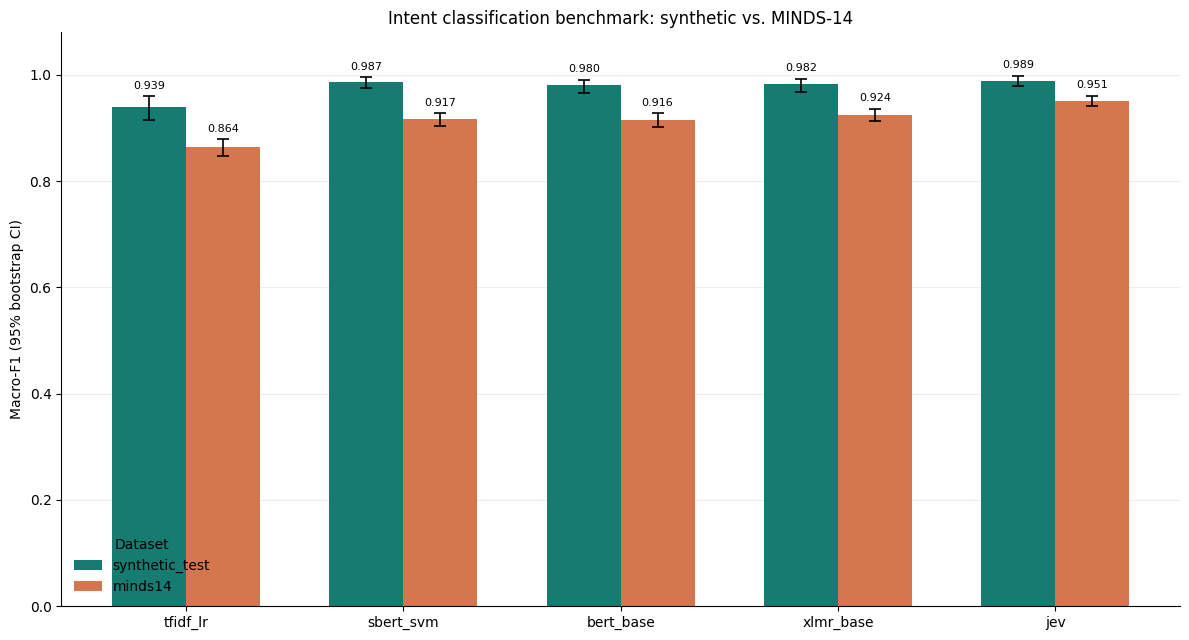

Saved ../results/benchmark.png


In [7]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
dataset_order = ['synthetic_test', 'minds14']
dataset_colors = {'synthetic_test': '#167C72', 'minds14': '#D4774E'}
model_order = [model for model in MODEL_METADATA if model in metrics_df['model'].unique()]
model_order.extend(sorted(set(metrics_df['model']) - set(model_order)))

fig, ax = plt.subplots(figsize=(12, 6.5))
x_positions = np.arange(len(model_order))
bar_width = 0.34

for dataset_index, dataset_name in enumerate(dataset_order):
    dataset_metrics = metrics_df.loc[metrics_df['dataset'] == dataset_name].set_index('model')
    offset = (dataset_index - (len(dataset_order) - 1) / 2) * bar_width
    for model_index, model_name in enumerate(model_order):
        if model_name not in dataset_metrics.index:
            continue
        row = dataset_metrics.loc[model_name]
        yerr = np.array([[row['macro_f1'] - row['ci_lower']], [row['ci_upper'] - row['macro_f1']]])
        bar = ax.bar(
            x_positions[model_index] + offset,
            row['macro_f1'],
            width=bar_width,
            color=dataset_colors.get(dataset_name, '#777777'),
            label=dataset_name if model_index == 0 else None,
            yerr=yerr,
            capsize=4,
            error_kw={'elinewidth': 1.2, 'capthick': 1.2},
        )
        ax.bar_label(bar, labels=[f"{row['macro_f1']:.3f}"], padding=4, fontsize=8)

ax.set_xticks(x_positions, model_order)
ax.set_ylabel('Macro-F1 (95% bootstrap CI)')
ax.set_ylim(0, 1.08)
ax.set_title('Intent classification benchmark: synthetic vs. MINDS-14')
ax.grid(axis='y', alpha=0.22)
ax.set_axisbelow(True)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='Dataset', frameon=False)
fig.tight_layout()
plt.savefig('../results/benchmark.png', bbox_inches='tight', dpi=300)
plt.show()
print('Saved ../results/benchmark.png')

## 8. Critical interpretation

Summarize the top model on each dataset, observed accuracy and macro-F1 changes from synthetic to real-world data for models present on both, and the implications and limits of the confidence intervals. The text below is generated from the computed benchmark rather than manually entered scores.

In [8]:
analysis_lines = ['## Findings', '']
best_by_dataset = {}
for dataset_name, dataset_table in dataset_tables.items():
    best = metrics_df.loc[metrics_df['dataset'] == dataset_name].sort_values('macro_f1', ascending=False).iloc[0]
    best_by_dataset[dataset_name] = best
    analysis_lines.append(
        f"- **{dataset_name}:** {best['model']} leads with accuracy {best['accuracy']:.4f}, "
        f"macro-F1 {best['macro_f1']:.4f}, and 95% CI {best['ci_95_f1']}."
    )

if 'synthetic_test' in best_by_dataset and 'minds14' in best_by_dataset:
    analysis_lines.append('')
    analysis_lines.append('**Synthetic-to-real change for models available on both datasets:**')
    common_models = sorted(
        set(metrics_df.loc[metrics_df['dataset'] == 'synthetic_test', 'model'])
        & set(metrics_df.loc[metrics_df['dataset'] == 'minds14', 'model'])
    )
    for model_name in common_models:
        synthetic_row = metrics_df.loc[(metrics_df['dataset'] == 'synthetic_test') & (metrics_df['model'] == model_name)].iloc[0]
        minds_row = metrics_df.loc[(metrics_df['dataset'] == 'minds14') & (metrics_df['model'] == model_name)].iloc[0]
        accuracy_drop = (synthetic_row['accuracy'] - minds_row['accuracy']) * 100
        f1_drop = (synthetic_row['macro_f1'] - minds_row['macro_f1']) * 100
        analysis_lines.append(
            f"- `{model_name}` drops {accuracy_drop:.2f} percentage points in accuracy "
            f"and {f1_drop:.2f} points in macro-F1."
        )

    synthetic_best = best_by_dataset['synthetic_test']
    synthetic_ci_width = synthetic_best['ci_upper'] - synthetic_best['ci_lower']
    real_best = best_by_dataset['minds14']
    analysis_lines.append('')
    analysis_lines.append(
        f"**Confidence and saturation:** the synthetic leader's macro-F1 is {synthetic_best['macro_f1']:.4f} "
        f"with a bootstrap interval width of {synthetic_ci_width:.4f}; this high score leaves little headroom "
        f"and is consistent with a near-saturated synthetic test set. The real-data leader scores "
        f"{real_best['macro_f1']:.4f} on MINDS-14, showing that synthetic performance alone overstates "
        f"generalization. Bootstrap intervals quantify test-set resampling uncertainty, not dataset shift; "
        f"paired intervals are the relevant evidence for model-to-model differences."
    )

if not paired_df.empty:
    significant_count = int(paired_df['significant_at_95pct'].sum())
    analysis_lines.extend(['', f"Paired comparisons with intervals excluding zero: {significant_count} of {len(paired_df)}."])

if not {'synthetic_test', 'minds14'}.issubset(set(metrics_df['dataset'])):
    analysis_lines.extend(['', 'A synthetic-to-MINDS-14 change cannot be calculated until prediction files for both datasets are available.'])

analysis_markdown = '\n'.join(analysis_lines)
display(Markdown(analysis_markdown))

## Findings

- **minds14:** jev leads with accuracy 0.9508, macro-F1 0.9510, and 95% CI [0.9407, 0.9608].
- **synthetic_test:** jev leads with accuracy 0.9889, macro-F1 0.9890, and 95% CI [0.9791, 0.9978].

**Synthetic-to-real change for models available on both datasets:**
- `bert_base` drops 6.52 percentage points in accuracy and 6.44 points in macro-F1.
- `jev` drops 3.81 percentage points in accuracy and 3.80 points in macro-F1.
- `sbert_svm` drops 6.74 percentage points in accuracy and 6.95 points in macro-F1.
- `tfidf_lr` drops 7.46 percentage points in accuracy and 7.46 points in macro-F1.
- `xlmr_base` drops 5.80 percentage points in accuracy and 5.77 points in macro-F1.

**Confidence and saturation:** the synthetic leader's macro-F1 is 0.9890 with a bootstrap interval width of 0.0187; this high score leaves little headroom and is consistent with a near-saturated synthetic test set. The real-data leader scores 0.9510 on MINDS-14, showing that synthetic performance alone overstates generalization. Bootstrap intervals quantify test-set resampling uncertainty, not dataset shift; paired intervals are the relevant evidence for model-to-model differences.

Paired comparisons with intervals excluding zero: 6 of 12.